# Load NFLVerse Play By Play Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
##import NflVerse Data

pbp = pd.read_csv(
    "https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.csv.gz",
    compression="gzip"
)

pbp.head(10)

/tmp/ipykernel_15147/2435075317.py:3: DtypeWarning: Columns (45,179,180,182,183,189,190,203,204,205,206,218,219,220,222,224,226,233,234,235,236,237,238,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  pbp = pd.read_csv(


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NaN,NaN,NaN,...,0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.352700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.190052,NaN,NaN,NaN,NaN,NaN,0.511128,-51.112807
3,85,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1,0,1.317340,0.939998,4.750889,3.0,0.666726,0.439110,0.668940,33.105969
4,115,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.694360,NaN,NaN,NaN,NaN,NaN,0.492038,50.796208
5,135,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.284150,NaN,NaN,NaN,NaN,NaN,0.716846,-71.684569
6,166,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.840574,NaN,NaN,NaN,NaN,NaN,0.756109,-75.610864
7,188,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,0.650589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,214,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.194728,NaN,NaN,NaN,NaN,NaN,0.430873,-43.087283
9,243,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.788527,1.147553,5.786526,4.0,0.664423,0.453707,0.614372,38.562781


In [ ]:
pbp.columns

Index(['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team',
       'season_type', 'week', 'posteam', 'posteam_type', 'defteam',
       ...
       'out_of_bounds', 'home_opening_kickoff', 'qb_epa', 'xyac_epa',
       'xyac_mean_yardage', 'xyac_median_yardage', 'xyac_success', 'xyac_fd',
       'xpass', 'pass_oe'],
      dtype='object', length=372)

In [ ]:
##Build fourth down df

fourth_downs = pbp[pbp['down'] == 4]
len(fourth_downs)

##Keep only 'go for it' attempts

go_for_it = fourth_downs[
    fourth_downs["play_type"].isin(["run", "pass"])
].copy()
len(go_for_it)
go_for_it.shape

(931, 372)

In [ ]:
##Create our target variable

go_for_it["converted"] = (
    go_for_it["yards_gained"] >= go_for_it["ydstogo"]
).astype(int)

go_for_it[
    [
        "ydstogo",
        "yards_gained",
        "converted",
        "yardline_100",
        "score_differential"
    ]
].head(10)

,ydstogo,yards_gained,converted,yardline_100,score_differential
176,1,6.0,1,24.0,-7.0
180,10,0.0,0,18.0,-7.0
341,2,10.0,1,10.0,-15.0
378,1,4.0,1,63.0,0.0
471,1,0.0,0,5.0,-17.0
495,5,0.0,0,33.0,-17.0
504,1,3.0,1,34.0,17.0
567,1,2.0,1,48.0,-7.0
582,1,1.0,1,1.0,-7.0
664,5,0.0,0,39.0,-1.0


In [ ]:
##How often do teams convert by distance?

conversion_rates = (
    go_for_it.groupby("ydstogo")["converted"]
    .mean()
    .round(2)
    .reset_index()

)

conversion_rates.head(10)

,ydstogo,converted
0,1,0.66
1,2,0.62
2,3,0.52
3,4,0.57
4,5,0.50
5,6,0.34
6,7,0.39
7,8,0.30
8,9,0.10
9,10,0.31


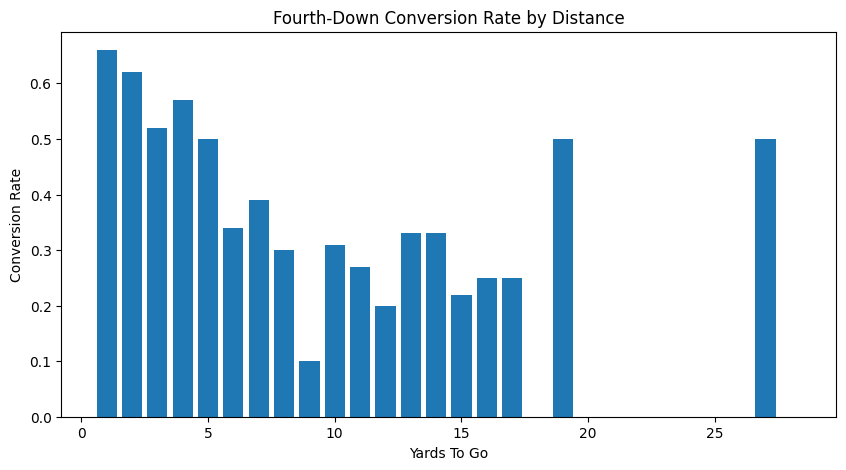

In [ ]:
##Visualize our conversion data

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    conversion_rates["ydstogo"],
    conversion_rates["converted"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()


The visualization above displays the fourth-down conversion rate by the distance required for a first down ('Yards To Go').

### Key Observations:
*   **Higher Conversion Rates for Shorter Distances:** As expected, teams show a higher propensity to convert fourth downs when the 'Yards To Go' is shorter, particularly within the 1-5 yard range. This aligns with typical strategic decisions in football.
*   **Anomalies at Longer Distances:** It's interesting to note the seemingly higher conversion rates at 18 and 27 yards to go, compared to the 5-15 yard range. While visually striking, these higher rates for longer distances (e.g., 18 and 27 yards) should be interpreted with caution. These attempts are likely much less frequent and may involve different play types or situations (e.g., Hail Mary passes, desperation plays) that don't represent a standard fourth-down attempt, thus skewing the conversion rate. The small sample size for these rare attempts can lead to volatile and potentially misleading conversion percentages.
*   **Decreasing Trend:** Generally, there's a clear decreasing trend in conversion rates as the 'Yards To Go' increases, indicating the increasing difficulty of converting longer distances.

In [ ]:
conversion_summary = (
    go_for_it.groupby("ydstogo")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

conversion_summary.head(20)

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
6,7,18,0.388889
7,8,27,0.296296
8,9,10,0.100000
9,10,32,0.312500


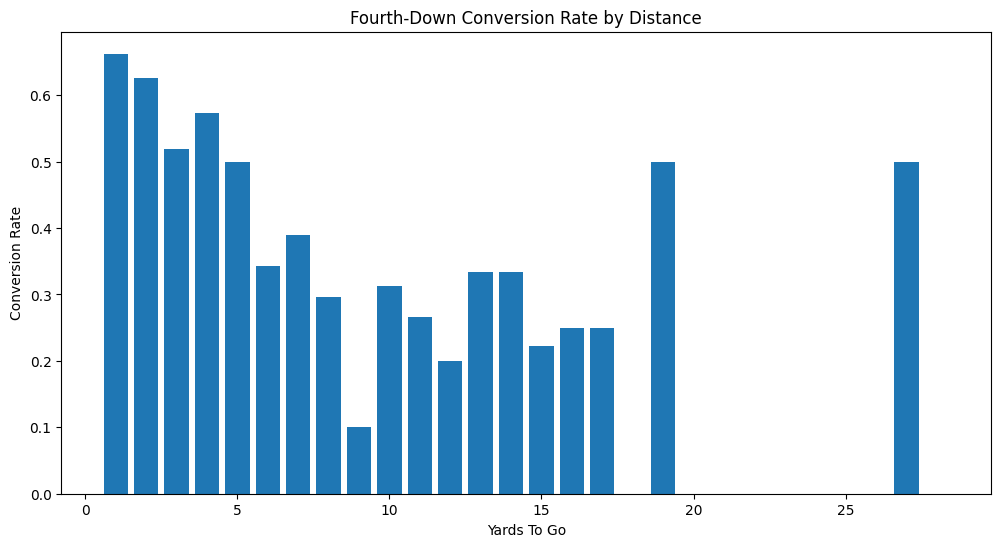

In [ ]:
##New visualization

plt.figure(figsize=(12,6))

plt.bar(
    conversion_summary["ydstogo"],
    conversion_summary["conversion_rate"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()

In [ ]:
conversion_summary[
    conversion_summary["attempts"] >= 20
]

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
7,8,27,0.296296
9,10,32,0.312500


In [ ]:
##Create zones of yards remaining to the endzone

go_for_it["field_zone"] = pd.cut(
    go_for_it["yardline_100"],
    bins=[0, 20, 50, 80, 100],
    labels=[
        "Red Zone",
        "Opponent Territory",
        "Midfield Area",
        "Own Territory"
    ]
)

##0-20 → close to scoring
##20-50 → opponent side
##50-80 → around midfield
##80-100 → backed up near own side

In [ ]:
##Analyzing conversion rates by zone

zone_summary = (
    go_for_it.groupby("field_zone")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

zone_summary

/tmp/ipykernel_15147/3960763139.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  go_for_it.groupby("field_zone")


,field_zone,attempts,conversion_rate
0,Red Zone,258,0.573643
1,Opponent Territory,417,0.522782
2,Midfield Area,244,0.573770
3,Own Territory,12,0.666667


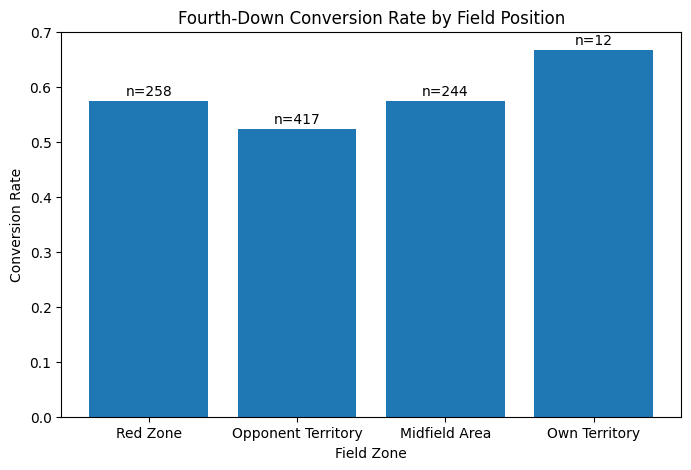

In [ ]:
##Visualize

plt.figure(figsize=(8,5))

bars = plt.bar(
    zone_summary["field_zone"],
    zone_summary["conversion_rate"]
)

# Adding sample size labels
for bar, attempts in zip(bars, zone_summary["attempts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={attempts}",
        ha='center'
    )

plt.ylabel("Conversion Rate")
plt.xlabel("Field Zone")
plt.title("Fourth-Down Conversion Rate by Field Position")

plt.show()

### Fourth-Down Conversion Rate by Field Position

The visualization above categorizes fourth-down attempts into four distinct field zones and shows their respective conversion rates along with the number of attempts (`n`).

#### Key Analytical Observations:

*   **Own Territory: High Efficiency, Low Volume:** The highest conversion rate is observed when teams attempt to convert a fourth down in their 'Own Territory' (66.7%). However, this also represents the smallest sample size with only 12 attempts. This suggests that coaches are extremely selective and likely only attempt these conversions in very favorable and high-confidence situations, or in desperate circumstances where the reward outweighs the risk.

*   **Red Zone vs. Midfield Area: Similar Effectiveness:** The 'Red Zone' and 'Midfield Area' show very similar conversion efficiencies, both hovering around 57%. This indicates that, despite the increased pressure and tighter defenses in the Red Zone, teams are converting fourth downs at a comparable rate to when they are around the middle of the field.

*   **Opponent Territory: Most Attempts, Lowest Rate:** 'Opponent Territory' sees the most fourth-down attempts (n=417) but surprisingly has the lowest conversion rate among all zones (52.3%). This suggests that while teams are most willing to 'go for it' on the opponent's side of the field, these situations are often more challenging than those selected in their own territory, or perhaps the yardage-to-go is frequently longer in these scenarios, contributing to a lower success rate. Additionally, the substantially larger sample size in Opponent Territory may provide a more statistically stable estimate of conversion efficiency compared to smaller-sample zones such as Own Territory. This aligns with the broader statistical principle that larger samples tend to produce more reliable estimates of underlying population behavior.

# Create Fourth Down Dataset

# Fourth Down Conversion Analytics

# Fourth Down Conversion Model

### Fourth-Down Conversion Rate by Distance and Field Zone

The graph shows that fourth-down attempts in the Red Zone, Midfield Area, and Opponent Territory all have very high conversion rates when teams only need one or two yards. This is expected because shorter distances generally lead to higher success rates.

One interesting finding is that, after removing weak sample sizes, there is no Red Zone data for attempts needing more than five yards. This likely reflects teams' preference to leave the Red Zone with high-percentage points from a field goal instead of risking a turnover on downs.

The Red Zone conversion pattern follows a very similar shape to the Midfield Area pattern. The main difference is that teams appear more willing to attempt fourth downs from farther distances near midfield. This may be because teams feel safe enough to take a risk in that part of the field while also recognizing that a field goal is not yet a high-probability scoring opportunity.

Opponent Territory behaves differently from the other zones. Its conversion rate comes closest to a downward-sloping pattern as yards to go increases. One result that stands out is that Opponent Territory has the highest conversion rate at 10 yards compared with the other field zones, suggesting that longer fourth-down attempts in this area may occur in specific game situations where teams are more selective or more motivated to keep the drive alive.